In [44]:
from sklearn.datasets import load_iris
import seaborn as sns
from sklearn.cluster import KMeans
import pandas as pd 
import numpy as np

In [45]:
iris  = load_iris()

In [46]:
X = iris.data
y = iris.target

In [47]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

visuals the data 

<Axes: >

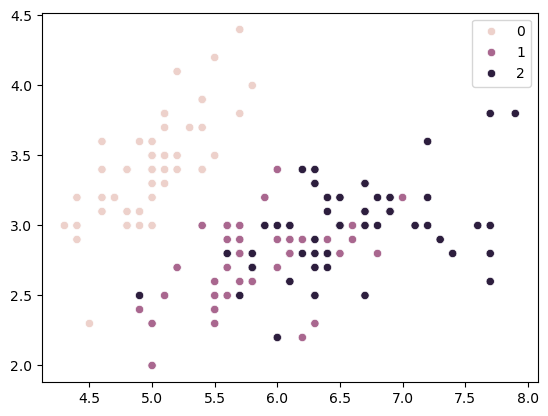

In [48]:
sns.scatterplot(x=X[:,0],y=X[:,1],hue=y)

### Cell 22 — t-SNE 2D Visualization (Beginner Notes)

This cell reduces the Iris feature data from 4 dimensions to 2 dimensions using **t-SNE** and then visualizes it using a scatter plot.

#### Functions and how they work

- `from sklearn.manifold import TSNE`  
  Imports the t-SNE algorithm from scikit-learn.

- `TSNE(...)`  
  Creates a t-SNE model object with settings:
  - `n_components=2`: output has 2 columns (x and y) for 2D plotting.
  - `random_state=42`: makes output reproducible (same result each run).
  - `init="pca"`: starts optimization from a PCA-based layout.
  - `learning_rate="auto"`: sklearn chooses a suitable learning rate.

- `.fit_transform(X)`  
  Learns the low-dimensional representation from `X` and returns transformed 2D coordinates (`X_2d`).

- `sns.scatterplot(...)`  
  Draws a 2D scatter chart of the transformed points:
  - `x=X_2d[:, 0]`, `y=X_2d[:, 1]`: first and second t-SNE axes.
  - `hue=y`: colors points by class label.
  - `palette="deep"`: color theme.
  - `s=60`: marker size.

#### Interpretation tips

- Nearby points are similar in the original feature space.
- Well-separated color groups suggest classes are distinguishable.
- t-SNE axis numbers are not direct physical units; relative distance/grouping is more important.

<Axes: >

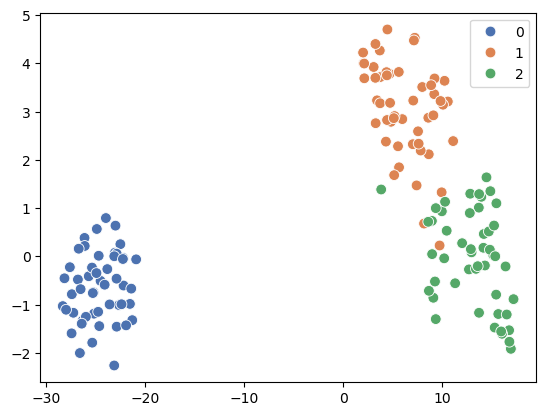

In [49]:
from sklearn.manifold import TSNE

X_2d = TSNE(
    n_components=2,
    random_state=42,
    init="pca",
    learning_rate="auto"
).fit_transform(X)

sns.scatterplot(x=X_2d[:, 0], y=X_2d[:, 1], hue=y, palette="deep", s=60)


### Cell 23 — 3D KMeans Cluster Visualization (Beginner Notes)

This cell applies **KMeans clustering** on Iris feature data and visualizes predicted cluster groups in a 3D scatter plot.

#### Step-by-step explanation of functions

- `import matplotlib.pyplot as plt`  
  Imports Matplotlib plotting tools.

- `KMeans(n_clusters=3, random_state=42, n_init=10)`  
  Creates a KMeans model:
  - `n_clusters=3`: asks algorithm to form 3 groups.
  - `random_state=42`: ensures reproducible centroid initialization.
  - `n_init=10`: runs KMeans 10 times with different initial centroids and keeps the best result (more stable than a single run).

- `.fit_predict(X)`  
  Two operations together:
  - **fit**: learns cluster centroids from data `X`.
  - **predict**: returns the cluster label for each sample.  
  Output is stored in `labels`.

- `fig = plt.figure()`  
  Creates a new figure container.

- `ax = fig.add_subplot(111, projection='3d')`  
  Adds one subplot in a 1×1 grid and enables 3D axes (`projection='3d'`).

- `ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=labels, cmap="viridis")`  
  Draws a 3D scatter plot:
  - `X[:, 0]`, `X[:, 1]`, `X[:, 2]`: first 3 features become x, y, z axes.
  - `c=labels`: point color depends on cluster assignment.
  - `cmap="viridis"`: color map used to display cluster colors.

- `plt.show()`  
  Renders and displays the plot.

#### Important beginner notes

- KMeans is **unsupervised**: it uses only `X` (features), not true target labels.
- Cluster IDs (`0`, `1`, `2`) are just group names, not quality scores.
- 3D visualization helps inspect separation, but cluster quality should also be checked with metrics (for example, inertia or silhouette score).

c:\Users\gk480\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


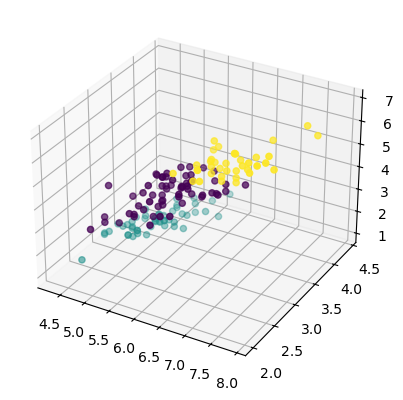

In [50]:
import matplotlib.pyplot as plt

labels = KMeans(n_clusters=3, random_state=42, n_init=10).fit_predict(X)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=labels, cmap="viridis")
plt.show()


In [51]:
from sklearn.preprocessing import StandardScaler

In [52]:
scaled = StandardScaler()

X_scaled = scaled.fit_transform(X)

In [53]:
# eblow method 

wcss = [] 
for k in range(1,10):
    kmean = KMeans(n_clusters=k)
    kmean.fit(X_scaled)
    wcss.append(kmean.inertia_)

    

c:\Users\gk480\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\gk480\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\gk480\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\gk480\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

<Axes: >

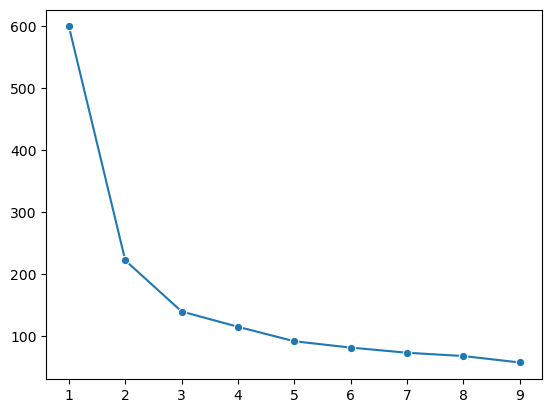

In [54]:
sns.lineplot(x=range(1,10),y=wcss,marker="o")

In [55]:
from kneed import KneeLocator

knee  =KneeLocator(range(1,10 ), wcss, curve='convex',direction='decreasing')

print("knee value :-",knee.elbow)

knee value :- 3


c:\Users\gk480\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


<Axes: >

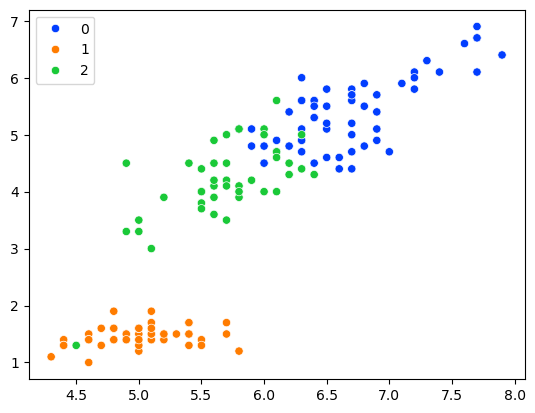

In [56]:
kmean = KMeans(n_clusters=3)
labels = kmean.fit_predict(X_scaled)

sns.scatterplot(x=X[:,0],y=X[:,2],hue= labels,palette="bright")

using dimensionality reduction

In [57]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

pca_data = pca.fit_transform(X_scaled)


In [58]:
wcss = [] 
for k in range(1,10):
    kmean = KMeans(n_clusters=k)
    kmean.fit(X_scaled)
    wcss.append(kmean.inertia_)

c:\Users\gk480\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\gk480\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\gk480\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\gk480\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

<Axes: >

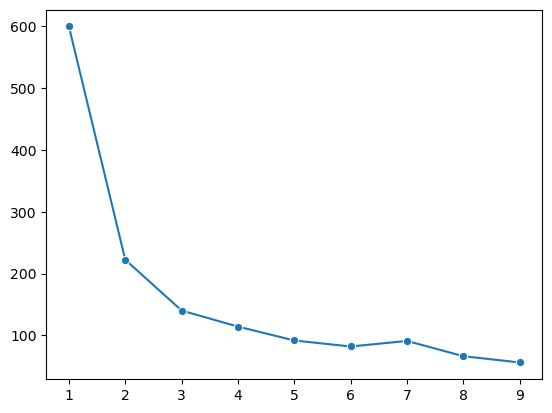

In [59]:
sns.lineplot(x=range(1,10),y=wcss,marker="o")

c:\Users\gk480\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


<Axes: >

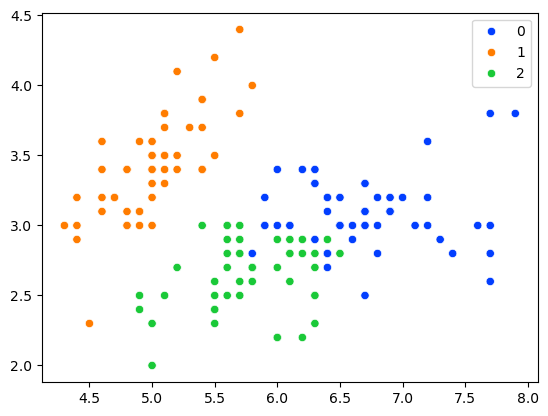

In [64]:
kmean = KMeans(n_clusters=3,random_state=2)
labels = kmean.fit_predict(X_scaled)

sns.scatterplot(x=X[:,0],y=X[:,1],hue= labels,palette="bright")


show centroid

<Axes: >

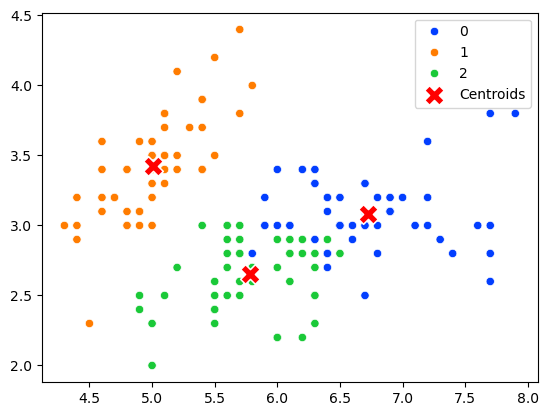

In [65]:
sns.scatterplot(x=X[:,0],y=X[:,1],hue= labels,palette="bright")
centroids = scaled.inverse_transform(kmean.cluster_centers_)
sns.scatterplot(
    x=centroids[:, 0],
    y=centroids[:, 1],
    marker="X",
    color="red",
    s=200,
    label="Centroids"
)